# Prédire la consommation énergétique des bâtiments (Seattle 2016)



## 1) Imports et paramètres

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib
import os

RANDOM_STATE = 42

## 2) Chargement des données





In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/P6_Anticipez_les_besoins_en_consommation_de_bâtiments/2016_Building_Energy_Benchmarking.csv"

building_consumption = pd.read_csv(DATA_PATH)

print("Shape:", building_consumption.shape)
display(building_consumption.head(3))


Shape: (3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3) Petit contrôle qualité



In [ ]:
TARGET = "SiteEnergyUse(kBtu)"

display(building_consumption[[TARGET]].describe())

missing = (building_consumption.isna().mean() * 100).sort_values(ascending=False)
dtypes = building_consumption.dtypes.astype(str)

qc = pd.DataFrame({"missing_%": missing, "dtype": dtypes})
display(qc.head(20))

,SiteEnergyUse(kBtu)
count,3.371000e+03
mean,5.403667e+06
std,2.161063e+07
min,0.000000e+00
25%,9.251286e+05
50%,1.803753e+06
75%,4.222455e+06
max,8.739237e+08


,missing_%,dtype
Address,0.000000,object
BuildingType,0.000000,object
City,0.000000,object
Comments,100.000000,float64
ComplianceStatus,0.000000,object
CouncilDistrictCode,0.000000,int64
DataYear,0.000000,int64
DefaultData,0.000000,bool
ENERGYSTARScore,24.970379,float64
Electricity(kBtu),0.266588,float64


## 4) Sélection des variables et anti-data-leakage


In [ ]:
df = building_consumption.dropna(subset=[TARGET]).copy()

# Variables post-consommation (énergie, intensités, émissions, etc.) -> leakage
LEAKAGE_COLS = [
    "Electricity(kBtu)", "Electricity(kWh)",
    "NaturalGas(kBtu)", "NaturalGas(therms)",
    "SteamUse(kBtu)", "SiteEnergyUseWN(kBtu)",
    "SourceEnergyUse(kBtu)",
    "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)",
    "WeatherNormalizedSiteEnergyUse",
    "TotalGHGEmissions", "GHGEmissionsIntensity",
    "ENERGYSTARScore", "YearsENERGYSTARCertified",
    "Comments"
]

present = [c for c in LEAKAGE_COLS if c in df.columns]
print("Leakage cols présentes (et supprimées):", present)

df = df.drop(columns=LEAKAGE_COLS, errors="ignore").copy()
print("Shape après suppression leakage:", df.shape)

SAFE_FEATURES = [
    "BuildingType",
    "PrimaryPropertyType",
    "Neighborhood",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseTypeGFA",
    "CouncilDistrictCode",
]

SAFE_FEATURES = [c for c in SAFE_FEATURES if c in df.columns]
print("SAFE_FEATURES utilisées:", SAFE_FEATURES)
print("Nb features:", len(SAFE_FEATURES))

df_model = df[SAFE_FEATURES + [TARGET]].copy()
print("Shape df_model:", df_model.shape)
display(df_model.head(3))

Leakage cols présentes (et supprimées): ['Electricity(kBtu)', 'Electricity(kWh)', 'NaturalGas(kBtu)', 'NaturalGas(therms)', 'SteamUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'ENERGYSTARScore', 'YearsENERGYSTARCertified', 'Comments']
Shape après suppression leakage: (3371, 31)
SAFE_FEATURES utilisées: ['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'PropertyGFAParking', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'CouncilDistrictCode']
Nb features: 15
Shape df_model: (3371, 16)


,BuildingType,PrimaryPropertyType,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFABuilding(s),PropertyGFAParking,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,SiteEnergyUse(kBtu)
0,NonResidential,Hotel,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,88434,0,88434.0,NaN,NaN,7,7226362.5
1,NonResidential,Hotel,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,88502,15064,83880.0,15064.0,4622.0,7,8387933.0
2,NonResidential,Hotel,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,759392,196718,756493.0,NaN,NaN,7,72587024.0


## 5) Feature engineering (simple, sans doublons)



In [ ]:
df_fe = df_model.copy()

# Âge du bâtiment (année dataset = 2016)
if "YearBuilt" in df_fe.columns:
    df_fe["BuildingAge"] = 2016 - df_fe["YearBuilt"]
    df_fe["BuildingAge"] = df_fe["BuildingAge"].clip(lower=0)

# Log surface
if "PropertyGFATotal" in df_fe.columns:
    df_fe["log_PropertyGFATotal"] = np.log1p(df_fe["PropertyGFATotal"])

# Ratio parking (calcul AVANT drop)
if "PropertyGFAParking" in df_fe.columns and "PropertyGFATotal" in df_fe.columns:
    df_fe["ParkingRatio"] = df_fe["PropertyGFAParking"] / df_fe["PropertyGFATotal"].replace(0, np.nan)

# Supprimer les anciennes colonnes (anti-doublons)
cols_to_drop = []
if "YearBuilt" in df_fe.columns:
    cols_to_drop.append("YearBuilt")
if "PropertyGFATotal" in df_fe.columns:
    cols_to_drop.append("PropertyGFATotal")
if cols_to_drop:
    df_fe = df_fe.drop(columns=cols_to_drop)

print("Dropped:", cols_to_drop)
print("Shape df_fe:", df_fe.shape)
display(df_fe.head(3))

# Contrôle anti-doublons
check_cols = ["BuildingAge", "log_PropertyGFATotal", "YearBuilt", "PropertyGFATotal"]
present_check = {c: (c in df_fe.columns) for c in check_cols}
present_check

Dropped: ['YearBuilt', 'PropertyGFATotal']
Shape df_fe: (3371, 17)


,BuildingType,PrimaryPropertyType,Neighborhood,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),PropertyGFAParking,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,CouncilDistrictCode,SiteEnergyUse(kBtu),BuildingAge,log_PropertyGFATotal,ParkingRatio
0,NonResidential,Hotel,DOWNTOWN,47.61220,-122.33799,1.0,12,88434,0,88434.0,NaN,NaN,7,7226362.5,89,11.390023,0.000000
1,NonResidential,Hotel,DOWNTOWN,47.61317,-122.33393,1.0,11,88502,15064,83880.0,15064.0,4622.0,7,8387933.0,20,11.547974,0.145453
2,NonResidential,Hotel,DOWNTOWN,47.61393,-122.33810,1.0,41,759392,196718,756493.0,NaN,NaN,7,72587024.0,47,13.770629,0.205748


{'BuildingAge': True,
 'log_PropertyGFATotal': True,
 'YearBuilt': False,
 'PropertyGFATotal': False}

## 6) Préparation X/y + split + preprocessing



In [ ]:
TARGET = "SiteEnergyUse(kBtu)"
df_prep = df_fe.dropna(subset=[TARGET]).copy()

X = df_prep.drop(columns=[TARGET])
y = np.log1p(df_prep[TARGET].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop",
    sparse_threshold=0  # IMPORTANT: sortie dense
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Num:", num_features)
print("Cat:", cat_features)

Xt = preprocess.fit_transform(X_train)
print(type(Xt), Xt.shape)

Train: (2696, 16) Test: (675, 16)
Num: ['Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFABuilding(s)', 'PropertyGFAParking', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'CouncilDistrictCode', 'BuildingAge', 'log_PropertyGFATotal', 'ParkingRatio']
Cat: ['BuildingType', 'PrimaryPropertyType', 'Neighborhood']
<class 'numpy.ndarray'> (2696, 62)


## 7) Comparaison de modèles

Je compare:
- Dummy median (baseline)
- Linear Regression
- Ridge
- Random Forest
- HistGradientBoosting

Je choisis le meilleur sur RMSE test (en log) et je garde aussi MAE et R2.

In [ ]:
candidates = [
    ("Dummy_median", DummyRegressor(strategy="median")),
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge(alpha=1.0)),
    ("RandomForest", RandomForestRegressor(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
    )),
    ("HistGradientBoosting", HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    )),
]

def eval_pipe(name, model):
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return pipe, {"model": name, "RMSE_test": rmse, "MAE_test": mae, "R2_test": r2}

rows = []
pipes = {}

for name, model in candidates:
    pipe, metrics = eval_pipe(name, model)
    pipes[name] = pipe
    rows.append(metrics)

results_models = pd.DataFrame(rows).sort_values("RMSE_test").reset_index(drop=True)
results_models["RMSE_test"] = results_models["RMSE_test"].round(6)
results_models["MAE_test"] = results_models["MAE_test"].round(6)
results_models["R2_test"] = results_models["R2_test"].round(6)
display(results_models)

best_name = results_models.loc[0, "model"]
best_pipe = pipes[best_name]
print("Best model:", best_name)

,model,RMSE_test,MAE_test,R2_test
0,Ridge,1.190983,0.547130,0.462783
1,LinearRegression,1.193723,0.558102,0.460308
2,HistGradientBoosting,1.197528,0.562749,0.456863
3,RandomForest,1.352419,0.568891,0.307275
4,Dummy_median,1.638503,1.004891,-0.016794


Best model: Ridge


## 8) Lecture des métriques en kBtu

In [ ]:
pred_log = best_pipe.predict(X_test)

y_true_kbtu = np.expm1(y_test)
y_pred_kbtu = np.expm1(pred_log)

rmse_kbtu = np.sqrt(mean_squared_error(y_true_kbtu, y_pred_kbtu))
mae_kbtu = mean_absolute_error(y_true_kbtu, y_pred_kbtu)
r2_log = r2_score(y_test, pred_log)

print("RMSE (kBtu):", round(rmse_kbtu, 0))
print("MAE  (kBtu):", round(mae_kbtu, 0))
print("R2 (log space):", round(r2_log, 3))

RMSE (kBtu): 21293390.0
MAE  (kBtu): 3099706.0
R2 (log space): 0.463


## 9) Interprétabilité globale

Si le meilleur modèle est Ridge, je peux interpréter via les coefficients.


,feature,coef,abs_coef
1,Longitude,1.583966,1.583966
22,PrimaryPropertyType_Hospital,1.494305,1.494305
19,BuildingType_SPS-District K-12,-1.486457,1.486457
37,PrimaryPropertyType_Self-Storage Facility,-1.381270,1.381270
25,PrimaryPropertyType_Laboratory,1.341519,1.341519
0,Latitude,-1.302165,1.302165
40,PrimaryPropertyType_Supermarket / Grocery Store,1.184857,1.184857
11,log_PropertyGFATotal,1.048968,1.048968
42,PrimaryPropertyType_Warehouse,-0.965151,0.965151
20,PrimaryPropertyType_Distribution Center,-0.888993,0.888993


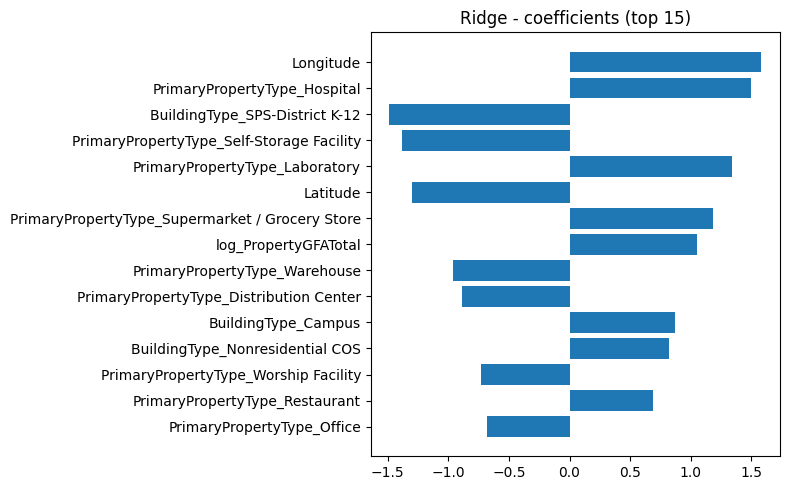

In [ ]:
# Noms des features après OneHot
pre = best_pipe.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_features)
feature_names = num_features + list(cat_names)

if hasattr(best_pipe.named_steps["model"], "coef_"):
    model = best_pipe.named_steps["model"]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": model.coef_
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)
    display(coef_df.head(20))

    top = coef_df.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["coef"])
    plt.title(f"{best_name} - coefficients (top 15)")
    plt.tight_layout()
    plt.show()
else:
    print("Le modèle retenu n'a pas coef_ (pas un modèle linéaire).")

## 10) Interprétabilité locale (Ridge) - contributions sur 1 bâtiment



,feature,value_proc,coef,contribution,abs_contribution
1,Longitude,-122.326160,1.583966,-193.760459,193.760459
0,Latitude,47.622650,-1.302165,-62.012529,62.012529
11,log_PropertyGFATotal,10.104713,1.048968,10.599525,10.599525
16,BuildingType_Multifamily MR (5-9),1.000000,-0.197741,-0.197741,0.197741
3,NumberofFloors,6.000000,0.017506,0.105035,0.105035
6,LargestPropertyUseTypeGFA,37618.000000,0.000002,0.077659,0.077659
4,PropertyGFABuilding(s),24457.000000,-0.000002,-0.059184,0.059184
8,ThirdLargestPropertyUseTypeGFA,4900.500000,0.000010,0.051441,0.051441
9,CouncilDistrictCode,3.000000,-0.015759,-0.047276,0.047276
51,Neighborhood_EAST,1.000000,0.040608,0.040608,0.040608


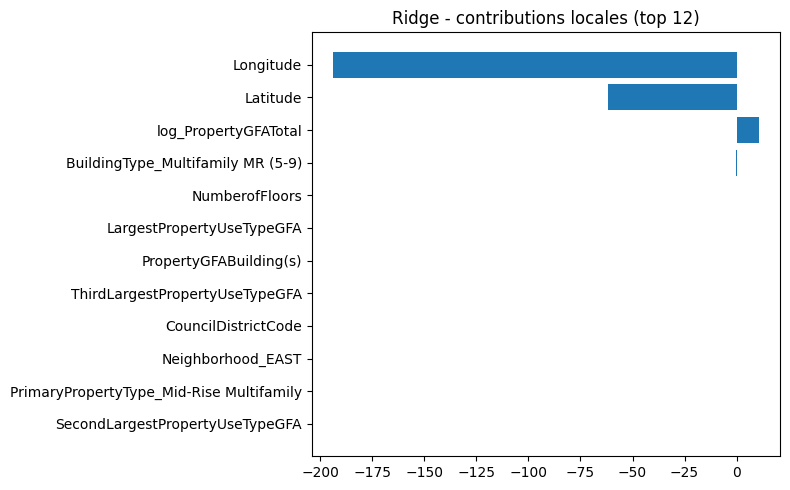

Intercept: 258.82869391988163
Prediction log: 13.654754091204751


/tmp/ipython-input-1326885432.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Prediction log:", float(best_pipe.predict(x1)))


In [ ]:
model = best_pipe.named_steps["model"]
pre = best_pipe.named_steps["preprocess"]

x1 = X_test.iloc[[0]].copy()
x1_proc = pre.transform(x1).reshape(-1)

if hasattr(model, "coef_"):
    contrib = x1_proc * model.coef_
    local_df = pd.DataFrame({
        "feature": feature_names,
        "value_proc": x1_proc,
        "coef": model.coef_,
        "contribution": contrib,
        "abs_contribution": np.abs(contrib)
    }).sort_values("abs_contribution", ascending=False)

    display(local_df.head(15))

    top = local_df.head(12).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["contribution"])
    plt.title(f"{best_name} - contributions locales (top 12)")
    plt.tight_layout()
    plt.show()

    print("Intercept:", float(getattr(model, "intercept_", 0.0)))
    print("Prediction log:", float(best_pipe.predict(x1)))
else:
    print("Je n'ai pas de coef_ - je saute l'explication locale linéaire.")

## 11) Diagnostic rapide - résidus



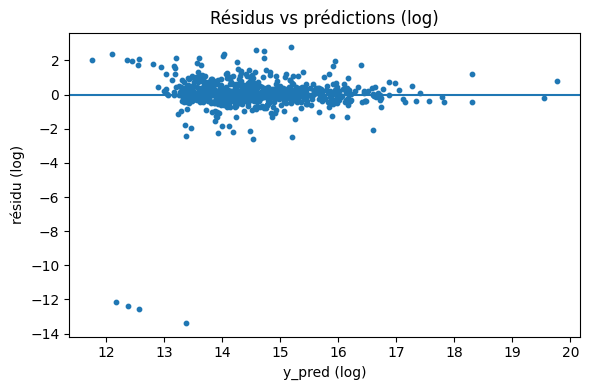

In [ ]:
pred_log = best_pipe.predict(X_test)
res = y_test - pred_log

plt.figure(figsize=(6, 4))
plt.scatter(pred_log, res, s=10)
plt.axhline(0)
plt.title("Résidus vs prédictions (log)")
plt.xlabel("y_pred (log)")
plt.ylabel("résidu (log)")
plt.tight_layout()
plt.show()

## 12) Sauvegarde du pipeline (prêt pour déploiement)



In [ ]:
os.makedirs("artifacts", exist_ok=True)
out_path = f"artifacts/best_pipe_{best_name}.joblib"
joblib.dump(best_pipe, out_path)
print("Saved:", out_path)

Saved: artifacts/best_pipe_Ridge.joblib


In [ ]:
from google.colab import files
files.download("artifacts/best_pipe_Ridge.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>